## Import Data

In [1]:
import pandas as pd
raw_data = pd.read_csv('../input/entity-annotated-corpus/ner_dataset.csv', encoding = "ISO-8859-1")

## Preprocessing

In [2]:
data_fillna = raw_data.fillna(method='ffill', axis=0)
data_group = data_fillna.groupby(['Sentence #'],as_index=False
                                )['Word', 'POS', 'Tag'].agg(lambda x: list(x))
data_group.head()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  This is separate from the ipykernel package so we can avoid doing imports until


,Sentence #,Word,POS,Tag
0,Sentence: 1,"[Thousands, of, demonstrators, have, marched, ...","[NNS, IN, NNS, VBP, VBN, IN, NNP, TO, VB, DT, ...","[O, O, O, O, O, O, B-geo, O, O, O, O, O, B-geo..."
1,Sentence: 10,"[Iranian, officials, say, they, expect, to, ge...","[JJ, NNS, VBP, PRP, VBP, TO, VB, NN, TO, JJ, J...","[B-gpe, O, O, O, O, O, O, O, O, O, O, O, O, O,..."
2,Sentence: 100,"[Helicopter, gunships, Saturday, pounded, mili...","[NN, NNS, NNP, VBD, JJ, NNS, IN, DT, NNP, JJ, ...","[O, O, B-tim, O, O, O, O, O, B-geo, O, O, O, O..."
3,Sentence: 1000,"[They, left, after, a, tense, hour-long, stand...","[PRP, VBD, IN, DT, NN, JJ, NN, IN, NN, NNS, .]","[O, O, O, O, O, O, O, O, O, O, O]"
4,Sentence: 10000,"[U.N., relief, coordinator, Jan, Egeland, said...","[NNP, NN, NN, NNP, NNP, VBD, NNP, ,, NNP, ,, J...","[B-geo, O, O, B-per, I-per, O, B-tim, O, B-geo..."


In [3]:
sequences = data_group['Word']
entities = data_group['Tag']

In [4]:
' '.join(sequences[4])

'U.N. relief coordinator Jan Egeland said Sunday , U.S. , Indonesian and Australian military helicopters are ferrying out food and supplies to remote areas of western Aceh province that ground crews can not reach .'

In [5]:
' '.join(entities[4])

'B-geo O O B-per I-per O B-tim O B-geo O B-gpe O B-gpe O O O O O O O O O O O O O B-geo O O O O O O O O'

In [6]:
len(sequences)

47959

In [7]:
for word, ent in zip(sequences[4], entities[4]):
    print(f'{word:{12}} {ent:{10}}')

U.N.         B-geo     
relief       O         
coordinator  O         
Jan          B-per     
Egeland      I-per     
said         O         
Sunday       B-tim     
,            O         
U.S.         B-geo     
,            O         
Indonesian   B-gpe     
and          O         
Australian   B-gpe     
military     O         
helicopters  O         
are          O         
ferrying     O         
out          O         
food         O         
and          O         
supplies     O         
to           O         
remote       O         
areas        O         
of           O         
western      O         
Aceh         B-geo     
province     O         
that         O         
ground       O         
crews        O         
can          O         
not          O         
reach        O         
.            O         


In [8]:
import numpy as np
def tokens_tags(data_X, data_y):
    vocab = []
    tags = []
    for seq in data_X:
        for word in np.unique(seq):
            if word.lower() not in vocab:
                vocab.append(word.lower())
    for seq_ent in data_y:
        for ent in seq_ent:
            if ent not in tags:
                tags.append(ent)
                
    return len(vocab), len(tags), max([len(s) for s in data_X])

num_tokens, num_tags, maxlen = tokens_tags(sequences, entities)
print('Number of unique tokens in data ', num_tokens)
print('Max length of sequence in data ', maxlen)
print('Number of unique tags in data ', num_tags)

Number of unique tokens in data  31817
Max length of sequence in data  104
Number of unique tags in data  17


In [9]:
import numpy as np
def data_words(data_X):
    vocab = []
    for seq in data_X:
        for word in seq:
            vocab.append(word)
                
    return len(vocab)

num_words = data_words(sequences)
print('Number of words  in data ', num_words)

Number of words  in data  1048575


## Encoding

In [10]:
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from keras.preprocessing import text, sequence

def encode_pad_data():
    tokenizer = text.Tokenizer(num_words=num_tokens+1, lower=True)
    label_tokenizer = text.Tokenizer(num_tags+1, lower=True)
    tokenizer.fit_on_texts(sequences)
    label_tokenizer.fit_on_texts(entities)
    
    encoded_sequences = tokenizer.texts_to_sequences(sequences)
    encoded_entities = label_tokenizer.texts_to_sequences(entities)
    
    encoded_entities = [to_categorical(i, num_classes=num_tags+1) for i in encoded_entities]
    
    pad_X = sequence.pad_sequences(encoded_sequences, dtype='int32', maxlen=maxlen, padding='post')
    pad_y = sequence.pad_sequences(encoded_entities, maxlen=maxlen, dtype='int32', padding='post')
    
    return maxlen, num_tags, pad_X, pad_y, tokenizer ,label_tokenizer

maxlen, num_tags, pad_X, pad_y, tokenizer ,label_tokenizer = encode_pad_data()

In [11]:
pad_X.shape, pad_y.shape

((47959, 104), (47959, 104, 18))

## Train Test Split

In [12]:
from sklearn.model_selection import train_test_split
train_inputs, test_inputs, train_targets, test_targets = train_test_split(pad_X, pad_y, test_size=0.2, random_state=42)

In [13]:
train_inputs.shape, test_inputs.shape, train_targets.shape, test_targets.shape

((38367, 104), (9592, 104), (38367, 104, 18), (9592, 104, 18))

In [37]:
import tensorflow as tf
from keras import backend as K

def mask(m, q):
    # Assumes m is 2D
    mask = tf.math.reduce_any(tf.not_equal(m, q), axis=-1)
    #return tf.boolean_mask(m, mask)
    return mask

def recall(y_true, y_pred):
    pad = tf.constant([0 for i in range(num_tags+1)], dtype=tf.float32)
    mask_ = mask(y_true, pad)
    masked_y_data = tf.boolean_mask(y_true, mask_)
    masked_y_pred = tf.boolean_mask(y_pred, mask_)
    true_positives = K.sum(K.round(K.clip(masked_y_data * masked_y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(masked_y_data, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision(y_true, y_pred):
    pad = tf.constant([0 for i in range(num_tags+1)], dtype=tf.float32)
    mask_ = mask(y_true, pad)
    masked_y_data = tf.boolean_mask(y_true, mask_)
    masked_y_pred = tf.boolean_mask(y_pred, mask_)
    true_positives = K.sum(K.round(K.clip(masked_y_data * masked_y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(masked_y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision


def f1(y_true, y_pred):
    precision_ = precision(y_true, y_pred)
    recall_ = recall(y_true, y_pred)
    return 2*((precision_*recall_)/(precision_+recall_+K.epsilon()))

## BiLSTM Model

In [38]:
#Now train the model
import tensorflow as tf
from tensorflow.keras import Sequential, Model, Input
from tensorflow.keras.layers import LSTM, Embedding, Dense, TimeDistributed, Dropout, Bidirectional, Lambda, Layer
from tensorflow.keras.utils import plot_model
from keras.optimizers import SGD, Adam, RMSprop

opt = Adam(0.01)
output_dim = 16
tf.random.set_seed(42)

sequence_input = Input(shape=(maxlen,), dtype=tf.int32, name='sequence_input')
outputs = Embedding(input_dim=num_tokens+1, output_dim=output_dim, trainable=True, mask_zero=True)(sequence_input)
outputs = Bidirectional(LSTM(units=output_dim, return_sequences=True, dropout=0.5, recurrent_dropout=0.5), merge_mode = 'concat')(outputs)
#outputs = LSTM(units=output_dim, return_sequences=True, dropout=0.5, recurrent_dropout=0.5)(outputs)
outputs = (Dense(num_tags+1, activation="softmax"))(outputs)

model = Model(inputs=sequence_input, outputs=outputs)
model.compile(loss='CategoricalCrossentropy', optimizer=opt, metrics=[f1, precision, recall])
model.summary()

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequence_input (InputLayer)  [(None, 104)]             0         
_________________________________________________________________
embedding_2 (Embedding)      (None, 104, 16)           509088    
_________________________________________________________________
bidirectional_2 (Bidirection (None, 104, 32)           4224      
_________________________________________________________________
dense_2 (Dense)              (None, 104, 18)           594       
Total params: 513,906
Trainable params: 513,906
Non-trainable params: 0
_________________________________________________________________


In [ ]:
his = model.fit(train_inputs, train_targets, epochs=20, batch_size=256, validation_split=0.1)

Epoch 1/20
135/135 [==============================] - 44s 261ms/step - loss: 0.2213 - f1: 0.6784 - precision: 0.7301 - recall: 0.6560 - val_loss: 0.0771 - val_f1: 0.9000 - val_precision: 0.9660 - val_recall: 0.8425
Epoch 2/20
135/135 [==============================] - 34s 251ms/step - loss: 0.0654 - f1: 0.9139 - precision: 0.9696 - recall: 0.8647 - val_loss: 0.0440 - val_f1: 0.9449 - val_precision: 0.9621 - val_recall: 0.9284
Epoch 3/20
135/135 [==============================] - 34s 253ms/step - loss: 0.0394 - f1: 0.9481 - precision: 0.9641 - recall: 0.9326 - val_loss: 0.0382 - val_f1: 0.9506 - val_precision: 0.9596 - val_recall: 0.9416
Epoch 4/20
135/135 [==============================] - 34s 251ms/step - loss: 0.0334 - f1: 0.9553 - precision: 0.9655 - recall: 0.9453 - val_loss: 0.0367 - val_f1: 0.9534 - val_precision: 0.9600 - val_recall: 0.9469
Epoch 5/20
135/135 [==============================] - 34s 254ms/step - loss: 0.0302 - f1: 0.9587 - precision: 0.9669 - recall: 0.9507 - val_

## Results

In [ ]:
import matplotlib.pyplot as plt

loss = his.history['loss']
f1 = his.history['f1']
val_loss = his.history['val_loss']
val_f1 = his.history['val_f1']
val_precision = his.history['val_precision']
precision = his.history['precision']
recall = his.history['recall']
val_recall = his.history['val_recall']
epochs = range(1, 21)

import math
xint = range(min(epochs), math.ceil(max(epochs))+1)

plt.figure(figsize=(25,15))
plt.plot(epochs, f1,  label="Training F1", linewidth=4)
plt.plot(epochs, val_f1, label="Validation F1", linewidth=4)
plt.xlabel('Epochs', fontsize=50)
plt.ylabel('F1 Score', fontsize=50)
plt.legend(fontsize=50)
plt.xticks(xint, fontsize=50, rotation=90)
plt.yticks(fontsize=50)
plt.grid()
plt.tight_layout()
plt.savefig('f1.pdf')
plt.show()

In [ ]:
plt.figure(figsize=(25,15))

plt.plot(epochs, loss,  label="Training Loss", linewidth=4.0)
plt.plot(epochs, val_loss, label="Validation Loss", linewidth=4.0)
plt.xlabel('Epochs', fontsize=50)
plt.ylabel('Loss', fontsize=50)
plt.legend(fontsize=50)
plt.xticks(xint, fontsize=50, rotation=90)
plt.yticks(fontsize=50)
plt.grid()
plt.tight_layout()
plt.savefig('loss.pdf')
plt.show()

In [ ]:
plt.figure(figsize=(25,15))

plt.plot(epochs, precision,  label="Training Precision",  linewidth=4.0)
plt.plot(epochs, val_precision, label="Validation Precision",  linewidth=4.0)
plt.xlabel('Epochs', fontsize=50)
plt.ylabel('Precision', fontsize=50)
plt.legend(fontsize=50)
plt.xticks(xint, fontsize=50, rotation=90)
plt.yticks(fontsize=50)
plt.grid()
plt.tight_layout()
plt.savefig('precision.pdf')
plt.show()

In [ ]:
plt.figure(figsize=(25,15))

plt.plot(epochs, recall,  label="Training Recall",  linewidth=4.0)
plt.plot(epochs, val_recall, label="Validation Recall",  linewidth=4.0)
plt.xlabel('Epochs', fontsize=50)
plt.ylabel('Recall', fontsize=50)
plt.legend(fontsize=50)
plt.xticks(xint, fontsize=50, rotation=90)
plt.yticks(fontsize=50)
plt.grid()
plt.tight_layout()
plt.savefig('recall.pdf')
plt.show()

## Test Data

In [21]:
model.evaluate(test_inputs, test_targets)

300/300 [==============================] - 11s 38ms/step - loss: 0.0352 - f1: 0.9578 - precision: 0.9609 - recall: 0.9547


[0.03515627980232239,
 0.9578267335891724,
 0.9609435200691223,
 0.9547348022460938]

In [22]:
inv_map = {v: k for k, v in label_tokenizer.word_index.items()}
inv_map

{1: 'o',
 2: 'b-geo',
 3: 'b-tim',
 4: 'b-org',
 5: 'i-per',
 6: 'b-per',
 7: 'i-org',
 8: 'b-gpe',
 9: 'i-geo',
 10: 'i-tim',
 11: 'b-art',
 12: 'b-eve',
 13: 'i-art',
 14: 'i-eve',
 15: 'b-nat',
 16: 'i-gpe',
 17: 'i-nat'}

In [23]:
np.unique(np.argmax(train_targets, axis=-1))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

testpred = model.predict(test_inputs)

ypred = np.argmax(testpred, axis=-1).flatten()
y = np.argmax(test_targets, axis=-1).flatten()

ytrue, yhat = [], []
for y_t, y_p in zip(y, ypred):
    if y_t != 0:
        ytrue.append(y_t)
        yhat.append(y_p)

y_actu = pd.Series(ytrue, name='Actual')
y_pred = pd.Series(yhat, name='Predicted')

df_confusion = pd.crosstab(y_actu, y_pred)
plt.figure(figsize=(25,15))
#cmap = sns.diverging_palette(220, 20, sep=20, as_cmap=True)
sns.heatmap(df_confusion, annot=True, robust=True, fmt='g', cbar=False, annot_kws={"size": 25})
sns.set(font_scale=3)
plt.xlabel('Predicted', fontsize=50)
plt.ylabel('Actual', fontsize=50)
plt.xticks(fontsize=35)
plt.yticks(fontsize=35)
plt.tight_layout()
plt.savefig('conf_matrix.pdf')
plt.show()

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

## BiLSTM with GloVe Embedding

In [25]:
import tensorflow as tf
from keras import backend as K

def mask(m, q):
    # Assumes m is 2D
    mask = tf.math.reduce_any(tf.not_equal(m, q), axis=-1)
    #return tf.boolean_mask(m, mask)
    return mask

def recall(y_true, y_pred):
    pad = tf.constant([0 for i in range(num_tags+1)], dtype=tf.float32)
    mask_ = mask(y_true, pad)
    masked_y_data = tf.boolean_mask(y_true, mask_)
    masked_y_pred = tf.boolean_mask(y_pred, mask_)
    true_positives = K.sum(K.round(K.clip(masked_y_data * masked_y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(masked_y_data, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision(y_true, y_pred):
    pad = tf.constant([0 for i in range(num_tags+1)], dtype=tf.float32)
    mask_ = mask(y_true, pad)
    masked_y_data = tf.boolean_mask(y_true, mask_)
    masked_y_pred = tf.boolean_mask(y_pred, mask_)
    true_positives = K.sum(K.round(K.clip(masked_y_data * masked_y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(masked_y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision


def f1(y_true, y_pred):
    precision_ = precision(y_true, y_pred)
    recall_ = recall(y_true, y_pred)
    return 2*((precision_*recall_)/(precision_+recall_+K.epsilon()))

In [26]:
embed_size=300

EMBEDDING_FILE = '../input/glove840b300dtxt/glove.840B.300d.txt'

embeddings_index = {}
with open(EMBEDDING_FILE, encoding='utf8') as f:
    for line in f:
        values = line.rstrip().rsplit(' ')
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
        
word_index = tokenizer.word_index
#num_words = min(max_features, len(word_index) + 1)
embedding_matrix = np.zeros((num_tokens+1, embed_size))
for word, i in word_index.items():
    #if i >= max_features:
    #    continue
    
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [27]:
#Now train the model
import tensorflow as tf
from tensorflow.keras import Sequential, Model, Input
from tensorflow.keras.layers import LSTM, Embedding, Dense, TimeDistributed, Dropout, Bidirectional, Lambda, Layer
from tensorflow.keras.utils import plot_model
from keras.optimizers import SGD, Adam, RMSprop

opt = Adam(0.01)
output_dim = 16
tf.random.set_seed(42)

sequence_input = Input(shape=(maxlen,), dtype=tf.int32, name='sequence_input')
outputs = Embedding(input_dim=num_tokens+1, output_dim=embed_size, weights=[embedding_matrix], trainable=True, mask_zero=True)(sequence_input)
outputs = Bidirectional(LSTM(units=output_dim, return_sequences=True, dropout=0.5, recurrent_dropout=0.5), merge_mode = 'concat')(outputs)
#outputs = LSTM(units=output_dim, return_sequences=True, dropout=0.5, recurrent_dropout=0.5)(outputs)
outputs = (Dense(num_tags+1, activation="softmax"))(outputs)

model = Model(inputs=sequence_input, outputs=outputs)
model.compile(loss='CategoricalCrossentropy', optimizer=opt, metrics=[f1, precision, recall])
model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequence_input (InputLayer)  [(None, 104)]             0         
_________________________________________________________________
embedding_1 (Embedding)      (None, 104, 300)          9545400   
_________________________________________________________________
bidirectional_1 (Bidirection (None, 104, 32)           40576     
_________________________________________________________________
dense_1 (Dense)              (None, 104, 18)           594       
Total params: 9,586,570
Trainable params: 9,586,570
Non-trainable params: 0
_________________________________________________________________


In [28]:
his = model.fit(train_inputs, train_targets, epochs=20, batch_size=256, validation_split=0.1)

Epoch 1/20
135/135 [==============================] - 157s 1s/step - loss: 0.1334 - f1: 0.7948 - precision: 0.8484 - recall: 0.7578 - val_loss: 0.0377 - val_f1: 0.9510 - val_precision: 0.9609 - val_recall: 0.9413
Epoch 2/20
135/135 [==============================] - 141s 1s/step - loss: 0.0332 - f1: 0.9553 - precision: 0.9657 - recall: 0.9452 - val_loss: 0.0313 - val_f1: 0.9580 - val_precision: 0.9647 - val_recall: 0.9514
Epoch 3/20
135/135 [==============================] - 139s 1s/step - loss: 0.0254 - f1: 0.9645 - precision: 0.9713 - recall: 0.9577 - val_loss: 0.0305 - val_f1: 0.9591 - val_precision: 0.9644 - val_recall: 0.9538
Epoch 4/20
135/135 [==============================] - 145s 1s/step - loss: 0.0226 - f1: 0.9676 - precision: 0.9733 - recall: 0.9620 - val_loss: 0.0304 - val_f1: 0.9607 - val_precision: 0.9654 - val_recall: 0.9560
Epoch 5/20
135/135 [==============================] - 138s 1s/step - loss: 0.0203 - f1: 0.9703 - precision: 0.9753 - recall: 0.9654 - val_loss: 0.03

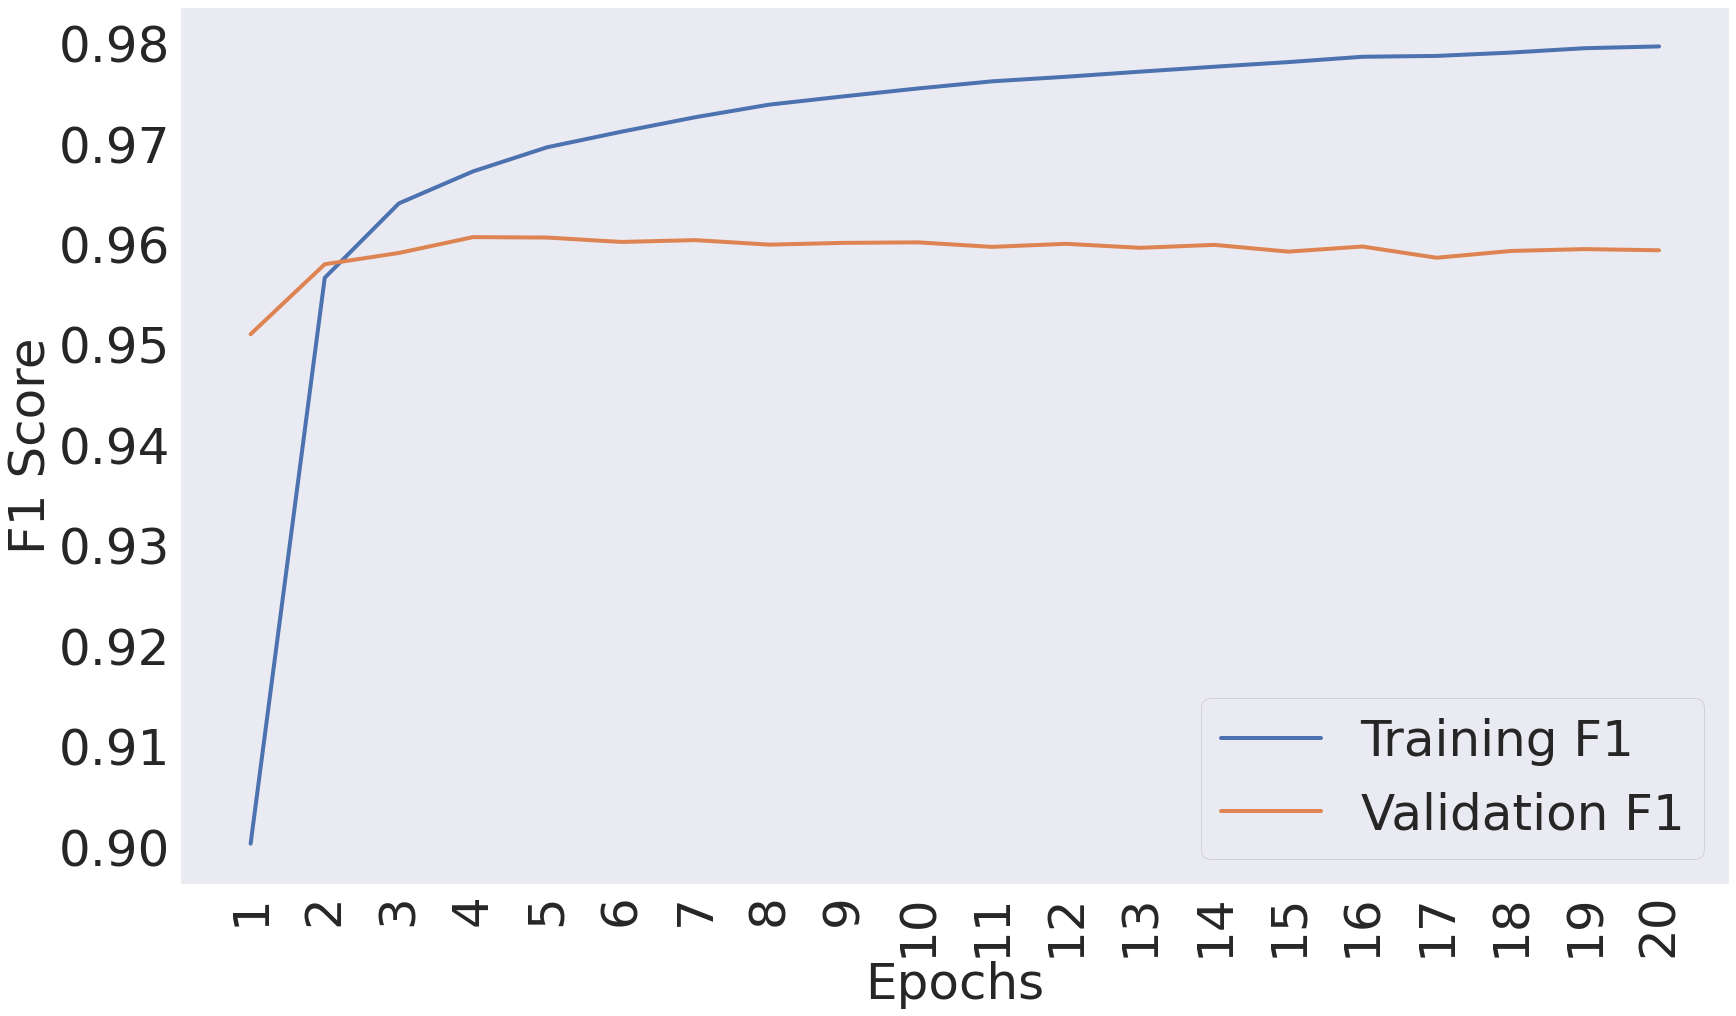

In [35]:
import matplotlib.pyplot as plt

loss = his.history['loss']
f1 = his.history['f1']
val_loss = his.history['val_loss']
val_f1 = his.history['val_f1']
val_precision = his.history['val_precision']
precision = his.history['precision']
recall = his.history['recall']
val_recall = his.history['val_recall']
epochs = range(1, 21)

import math
xint = range(min(epochs), math.ceil(max(epochs))+1)

plt.figure(figsize=(25,15))
plt.plot(epochs, f1,  label="Training F1", linewidth=4)
plt.plot(epochs, val_f1, label="Validation F1", linewidth=4)
plt.xlabel('Epochs', fontsize=50)
plt.ylabel('F1 Score', fontsize=50)
plt.legend(fontsize=50)
plt.xticks(xint, fontsize=50, rotation=90)
plt.yticks(fontsize=50)
plt.grid()
plt.tight_layout()
plt.savefig('glove_f1.pdf')
plt.show()

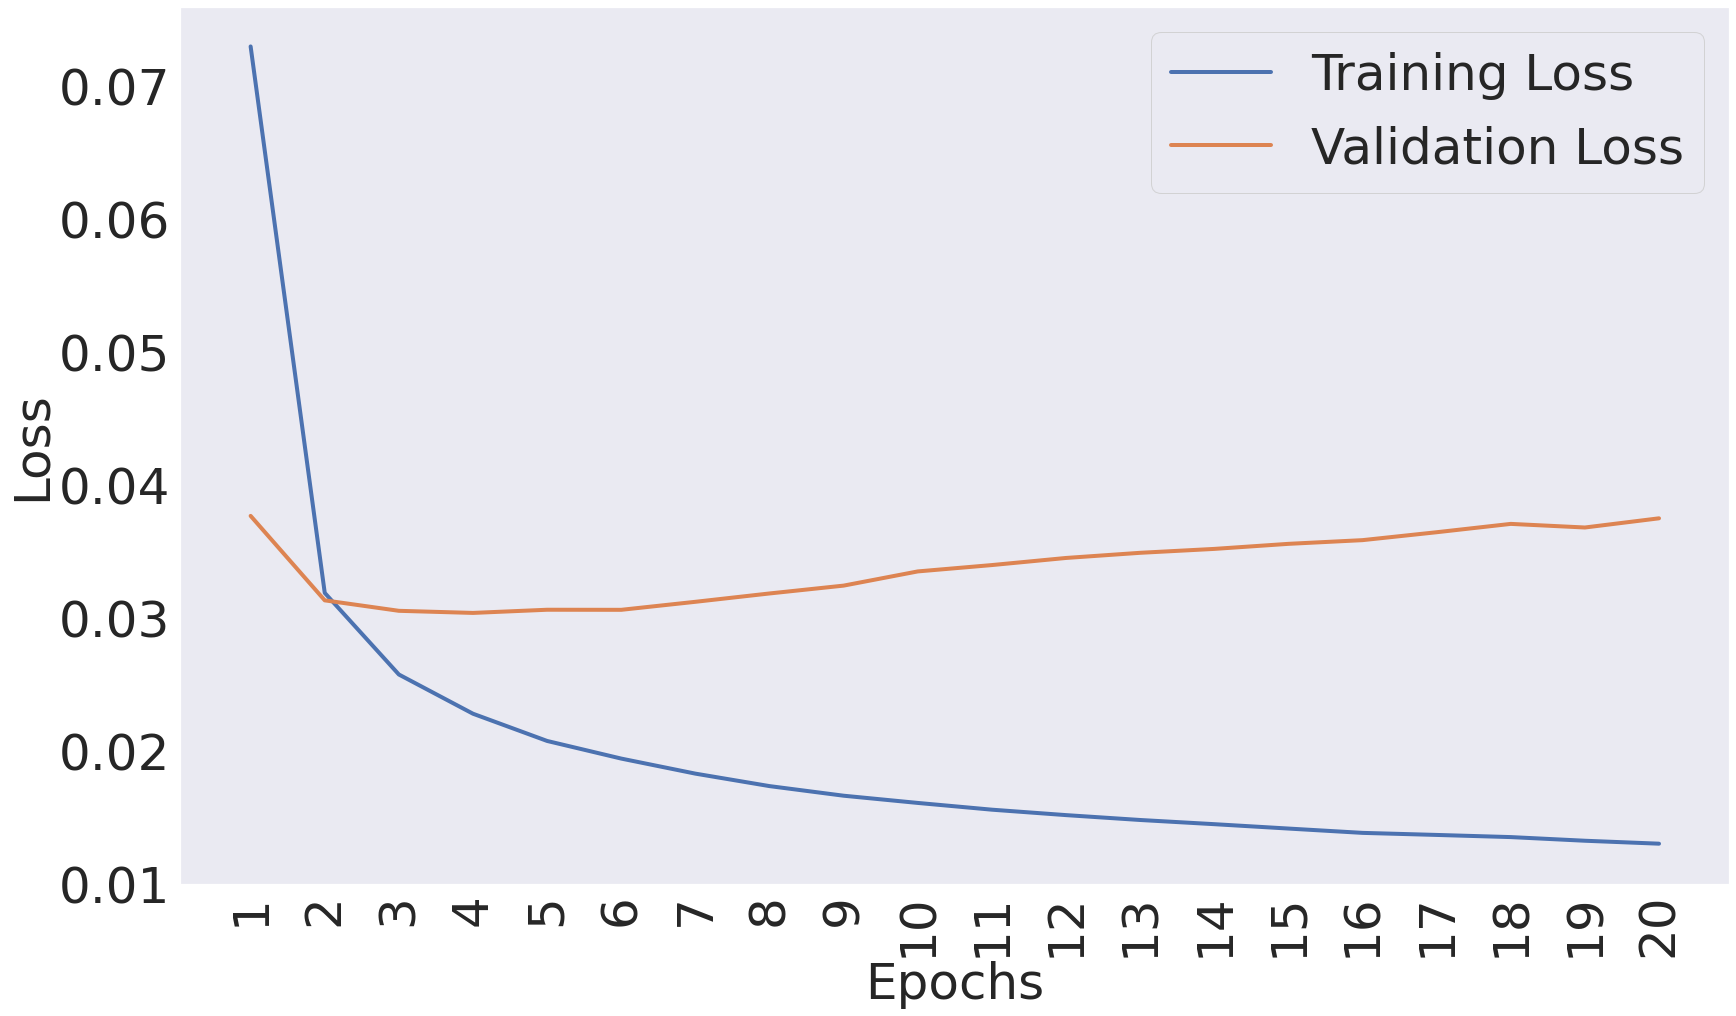

In [30]:
plt.figure(figsize=(25,15))

plt.plot(epochs, loss,  label="Training Loss", linewidth=4)
plt.plot(epochs, val_loss, label="Validation Loss", linewidth=4)
plt.xlabel('Epochs', fontsize=50)
plt.ylabel('Loss', fontsize=50)
plt.legend(fontsize=50)
plt.xticks(xint, fontsize=50, rotation=90)
plt.yticks(fontsize=50)
plt.grid()
plt.tight_layout()
plt.savefig('glove_loss.pdf')
plt.show()

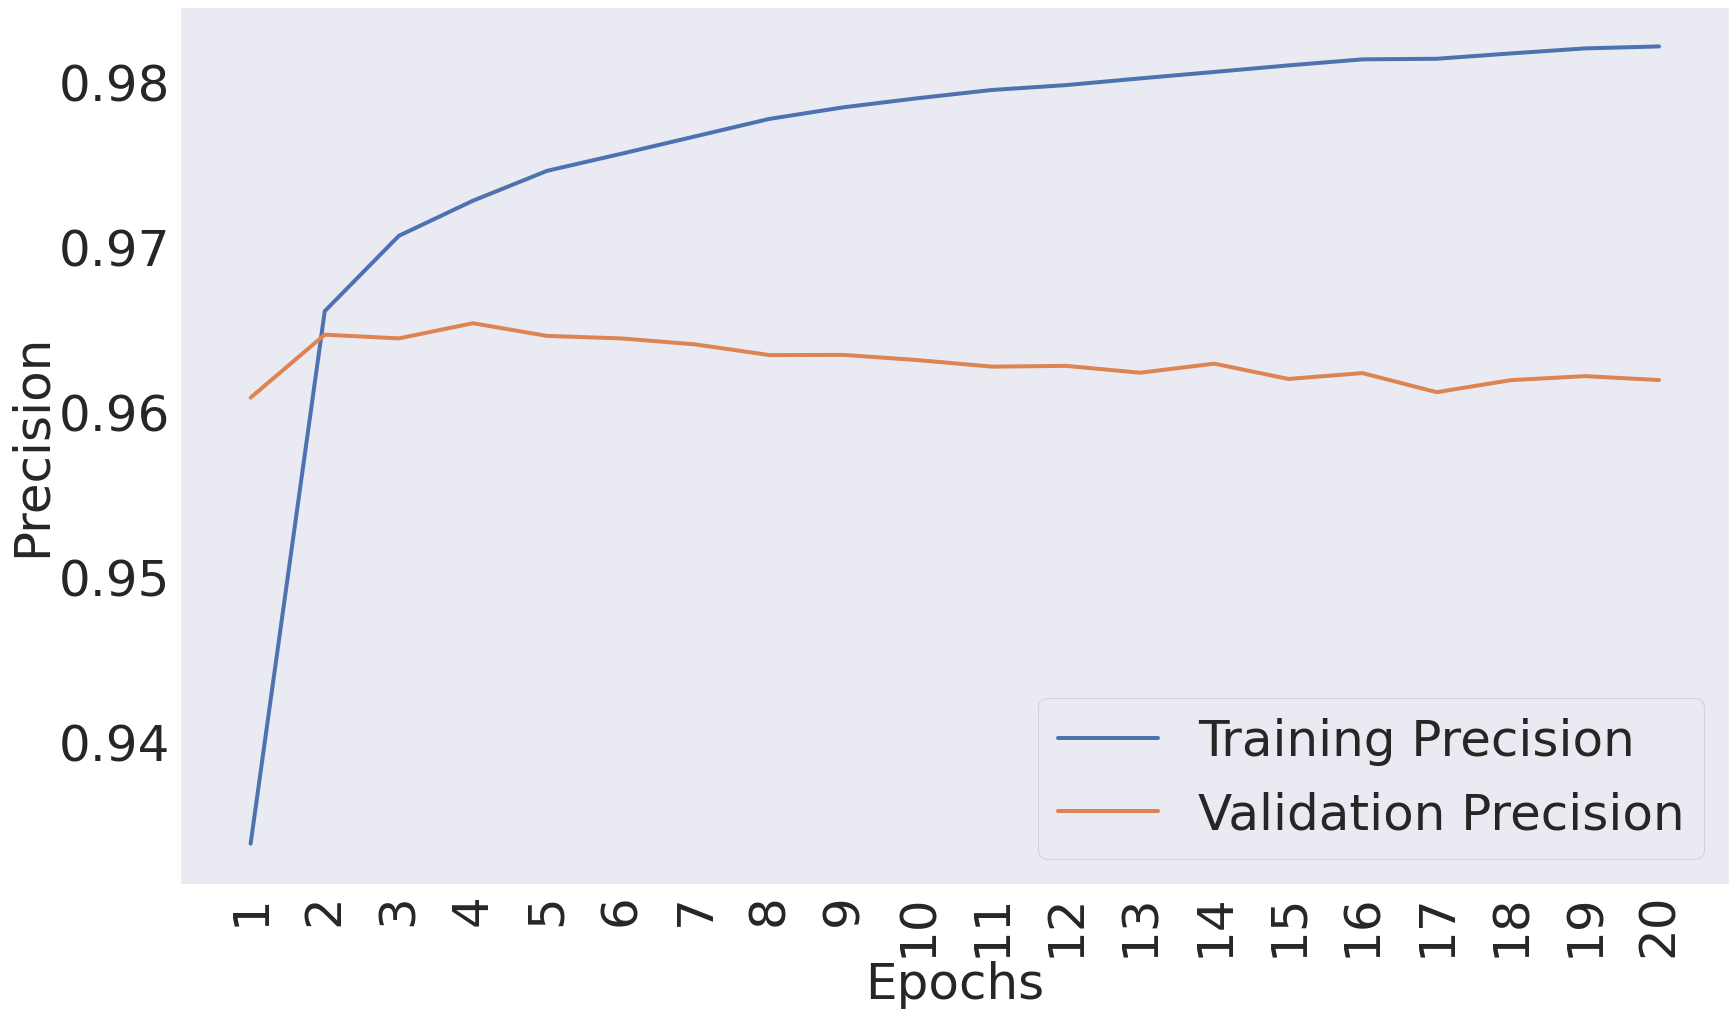

In [31]:
plt.figure(figsize=(25,15))

plt.plot(epochs, precision,  label="Training Precision",  linewidth=4.0)
plt.plot(epochs, val_precision, label="Validation Precision",  linewidth=4.0)
plt.xlabel('Epochs', fontsize=50)
plt.ylabel('Precision', fontsize=50)
plt.legend(fontsize=50)
plt.xticks(xint, fontsize=50, rotation=90)
plt.yticks(fontsize=50)
plt.grid()
plt.tight_layout()
plt.savefig('glove_precision.pdf')
plt.show()

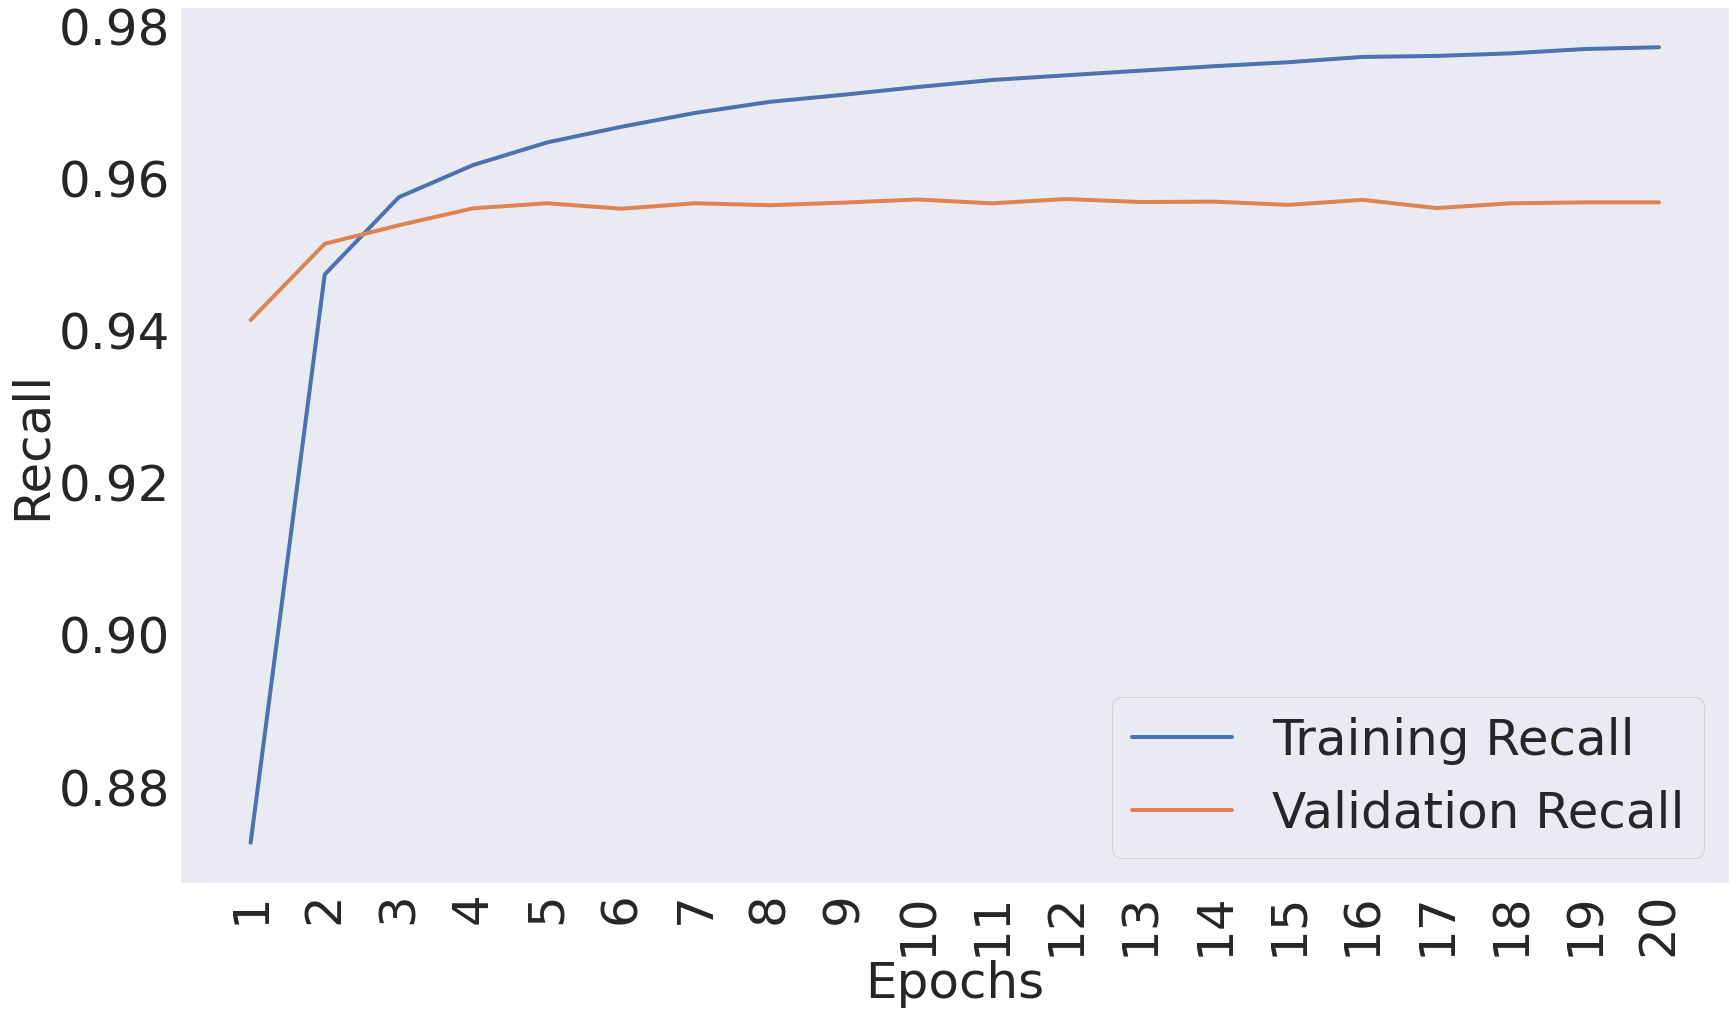

In [32]:
plt.figure(figsize=(25,15))

plt.plot(epochs, recall,  label="Training Recall",  linewidth=4.0)
plt.plot(epochs, val_recall, label="Validation Recall",  linewidth=4.0)
plt.xlabel('Epochs', fontsize=50)
plt.ylabel('Recall', fontsize=50)
plt.legend(fontsize=50)
plt.xticks(xint, fontsize=50, rotation=90)
plt.yticks(fontsize=50)
plt.grid()
plt.tight_layout()
plt.savefig('glove_recall.pdf')
plt.show()

## Test Data

In [33]:
model.evaluate(test_inputs, test_targets)

300/300 [==============================] - 11s 35ms/step - loss: 0.0365 - f1: 0.9606 - precision: 0.9630 - recall: 0.9581


[0.036536768078804016,
 0.9605509638786316,
 0.9629906415939331,
 0.958128035068512]

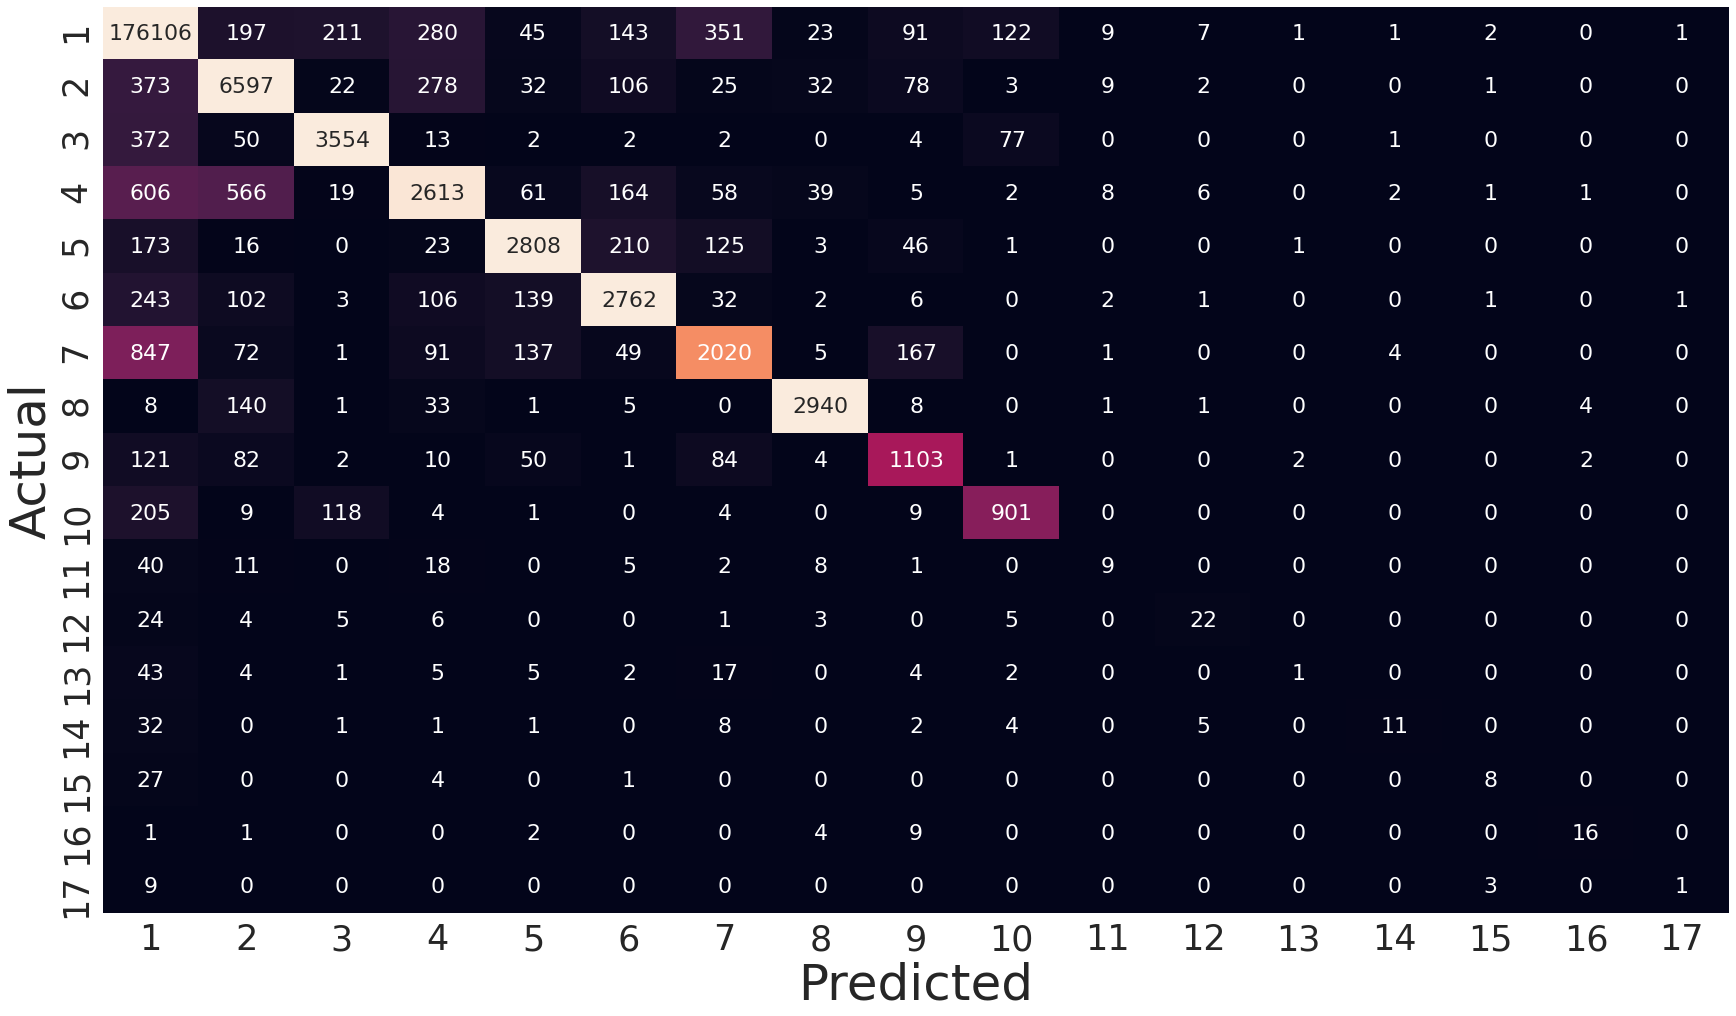

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

testpred = model.predict(test_inputs)

ypred = np.argmax(testpred, axis=-1).flatten()
y = np.argmax(test_targets, axis=-1).flatten()

ytrue, yhat = [], []
for y_t, y_p in zip(y, ypred):
    if y_t != 0:
        ytrue.append(y_t)
        yhat.append(y_p)

y_actu = pd.Series(ytrue, name='Actual')
y_pred = pd.Series(yhat, name='Predicted')

df_confusion = pd.crosstab(y_actu, y_pred)
plt.figure(figsize=(25,15))
sns.heatmap(df_confusion, annot=True, robust=True, fmt='g', cbar=False, annot_kws={"size": 22})

plt.xlabel('Predicted', fontsize=50)
plt.ylabel('Actual', fontsize=50)
plt.xticks(fontsize=35)
plt.yticks(fontsize=35)
plt.tight_layout()
plt.savefig('glove_conf_matrix.pdf')
plt.show()

# References:

- https://github.com/snehalnair/Named-Entity-Recognition
    
- https://www.kaggle.com/abhinavwalia95/entity-annotated-corpus?select=ner_dataset.csv